In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
#plt.rcParams['figure.figsize'] = (12, 6)

### EDA

In [2]:
df = pd.read_csv('/content/SCMS_Delivery_History_data.csv')
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [4]:
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [5]:
print(f"Shape: {df.shape}")
print(f"Missing Values (Raw):\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"Missing Freight Costs (Raw): {df['Freight Cost (USD)'].isnull().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Semantic Placeholders in Freight (e.g., 'See DN...'): {df['Freight Cost (USD)'].astype(str).str.contains('See').sum()}")

Shape: (10324, 33)
Missing Values (Raw):
Shipment Mode                 360
Dosage                       1736
Line Item Insurance (USD)     287
dtype: int64
Missing Freight Costs (Raw): 0
Duplicate Rows: 0
Semantic Placeholders in Freight (e.g., 'See DN...'): 2445


In [6]:
rows, _ = df.shape
missing_values_shipment_mode = ((df['Shipment Mode'].isnull().sum() * 100) / rows)
missing_values_Dosage = ((df['Dosage'].isnull().sum() * 100) / rows)
missing_values_Line_Item_Insurance = ((df['Line Item Insurance (USD)'].isnull().sum() * 100) / rows)

print(f"Missing Values in Shipment Mode: {missing_values_shipment_mode:.2f}%")
print(f"Missing Values in Dosage: {missing_values_Dosage:.2f}%")
print(f"Missing Values in Line Item Insurance: {missing_values_Line_Item_Insurance:.2f}%")

Missing Values in Shipment Mode: 3.49%
Missing Values in Dosage: 16.82%
Missing Values in Line Item Insurance: 2.78%


<Axes: >

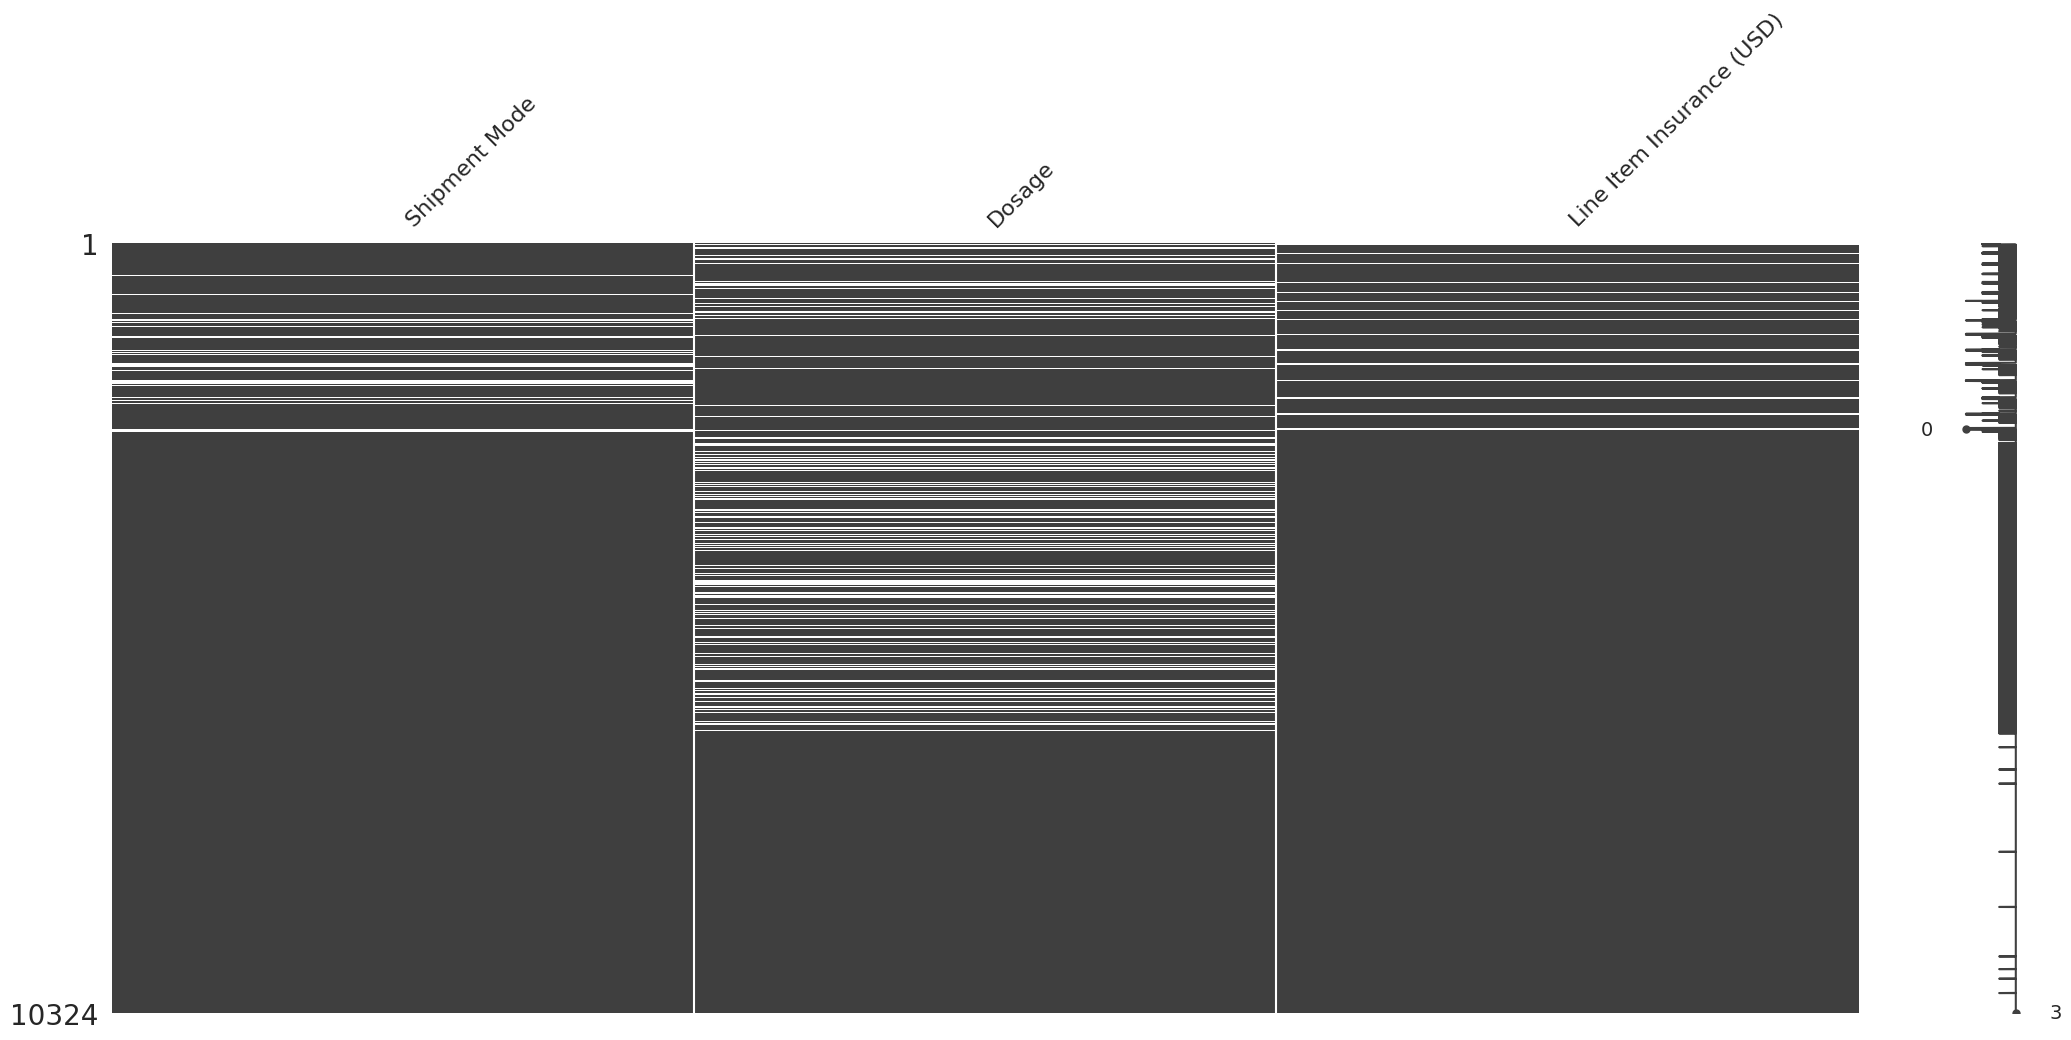

In [7]:
msno.matrix(df[['Shipment Mode', 'Dosage', 'Line Item Insurance (USD)']]) # for visualizing the missing data in the dataset

In [8]:
print(f'The columns names: {df.columns}')
print(f'Count of columns: {len(df.columns)}')

The columns names: Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')
Count of columns: 33


In [9]:
limited_columns_values = ['Managed By', 'Fulfill Via', 'Vendor INCO', 'Shipment Mode', 'Product Group', 'Sub Classification', 'First Line Designation']
for col in limited_columns_values:
  if col in df.columns:
    print(f'The values of {col} column is: {df[col].unique()}')
  #print(f'The values of {col} column is: {df[col].unique()}')

The values of Managed By column is: ['PMO - US' 'South Africa Field Office' 'Haiti Field Office'
 'Ethiopia Field Office']
The values of Fulfill Via column is: ['Direct Drop' 'From RDC']
The values of Shipment Mode column is: ['Air' nan 'Truck' 'Air Charter' 'Ocean']
The values of Product Group column is: ['HRDT' 'ARV' 'ACT' 'MRDT' 'ANTM']
The values of Sub Classification column is: ['HIV test' 'Pediatric' 'Adult' 'HIV test - Ancillary' 'ACT' 'Malaria']
The values of First Line Designation column is: ['Yes' 'No']


### Cleaning

In [10]:
cols_to_clean = ['Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)']
na_placeholders = ['Weight Captured Separately', 'Invoiced Separately',
                   'Freight Included in Commodity Cost', 'Not Applicable']

In [11]:
for col in cols_to_clean:
  if col in df.columns:
    df[col] = df[col].replace(na_placeholders, np.nan)
    df[col] = df[col].astype(str).str.replace(r'^See\s(DN|ASN).*', 'nan', regex = True)
    df[col] = df[col].replace('nan', np.nan)
    df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [12]:
print(df[cols_to_clean].head())

   Weight (Kilograms)  Freight Cost (USD)  Line Item Insurance (USD)
0                13.0              780.34                        NaN
1               358.0             4521.50                        NaN
2               171.0             1653.78                        NaN
3              1855.0            16007.06                        NaN
4              7590.0            45450.08                        NaN


In [13]:
cols_to_drop = ['PQ #', 'ASN/DN #', 'Process Step']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print("1. Dropped database IDs and non-analytical columns.")

1. Dropped database IDs and non-analytical columns.


In [14]:
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown / Internal Transfer')
print("2. Imputed missing 'Shipment Mode' with 'Unknown / Internal Transfer'.")

2. Imputed missing 'Shipment Mode' with 'Unknown / Internal Transfer'.


In [15]:
critical_dims = ['Country', 'Product Group', 'Scheduled Delivery Date']
initial_rows = rows
df.dropna(subset=[c for c in critical_dims if c in df.columns], inplace=True)
print(f"3. Dropped {initial_rows - rows} rows missing critical business dimensions (Country/Product).")

3. Dropped 0 rows missing critical business dimensions (Country/Product).


In [16]:
date_cols = ['PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date']
for col in date_cols:
    if col in df.columns:
        # Replace text placeholders with NaN before parsing
        df[col] = df[col].replace(['Pre-PQ Process', 'Date Not Captured', 'N/A - From RDC'], np.nan)
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [17]:
if 'PO Sent to Vendor Date' in df.columns and 'Delivered to Client Date' in df.columns:
    df['Lead Time (Days)'] = (df['Delivered to Client Date'] - df['PO Sent to Vendor Date']).dt.days
    # Filter out impossible data entry errors (e.g., negative days or > 3 years)
    df.loc[(df['Lead Time (Days)'] < 0) | (df['Lead Time (Days)'] > 1000), 'Lead Time (Days)'] = np.nan

print(f"\n--- FINAL CLEANED SHAPE: {df.shape} ---")


--- FINAL CLEANED SHAPE: (10324, 32) ---


In [18]:
df.columns

Index(['ID', 'Project Code', 'PO / SO #', 'Country', 'Managed By',
       'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)', 'Lead Time (Days)'],
      dtype='object')

In [19]:
df['Lead Time (Days)'].head(20)

,Lead Time (Days)
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,78.0


In [20]:
df.to_csv('cleaned_SMCS_data.csv', index=False)

### Visualization

In [21]:
if 'PO Sent to Vendor Date' in df.columns and 'Delivered to Client Date' in df.columns:
    df['Lead Time (Days)'] = (pd.to_datetime(df['Delivered to Client Date'], errors='coerce') -
                              pd.to_datetime(df['PO Sent to Vendor Date'], errors='coerce')).dt.days

# B. On-Time In-Full (OTIF)
if 'Scheduled Delivery Date' in df.columns and 'Delivered to Client Date' in df.columns:
    df['On_Time'] = pd.to_datetime(df['Delivered to Client Date'], errors='coerce') <= pd.to_datetime(df['Scheduled Delivery Date'], errors='coerce')

# C. Commodity Value (FIX: Using 'Line Item Quantity' instead of 'Quantity')
if 'Line Item Quantity' in df.columns and 'Unit Price' in df.columns:
    df['Commodity Value (USD)'] = pd.to_numeric(df['Line Item Quantity'], errors='coerce') * pd.to_numeric(df['Unit Price'], errors='coerce')

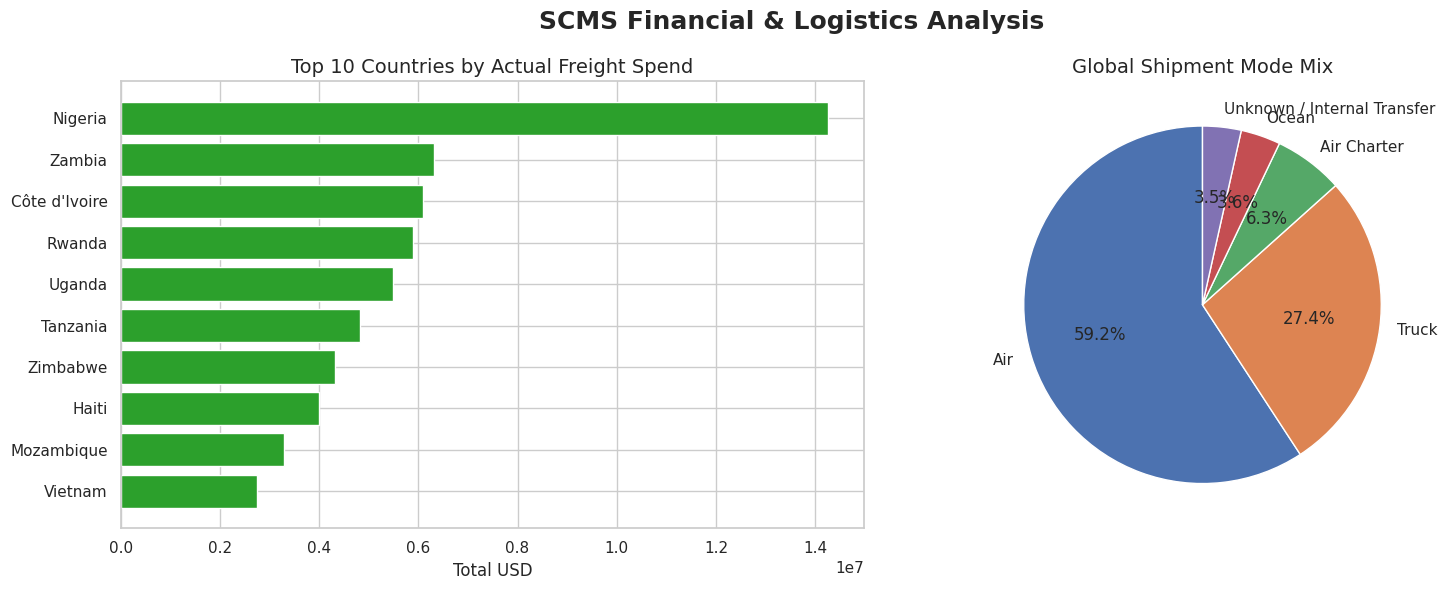

In [22]:
# VISUALIZATION 1: FINANCIAL & LOGISTICS OVERVIEW

fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle('SCMS Financial & Logistics Analysis', fontsize=18, fontweight='bold')

# Plot 1: Freight Spend by Country
freight_by_country = df.groupby('Country')['Freight Cost (USD)'].sum().dropna().nlargest(10).sort_values()
axes[0].barh(freight_by_country.index, freight_by_country.values, color='#2ca02c')
axes[0].set_title('Top 10 Countries by Actual Freight Spend', fontsize=14)
axes[0].set_xlabel('Total USD')

# Plot 2: Shipment Mode Mix
mode_counts = df['Shipment Mode'].value_counts()
axes[1].pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Global Shipment Mode Mix', fontsize=14)
plt.tight_layout()
plt.show()

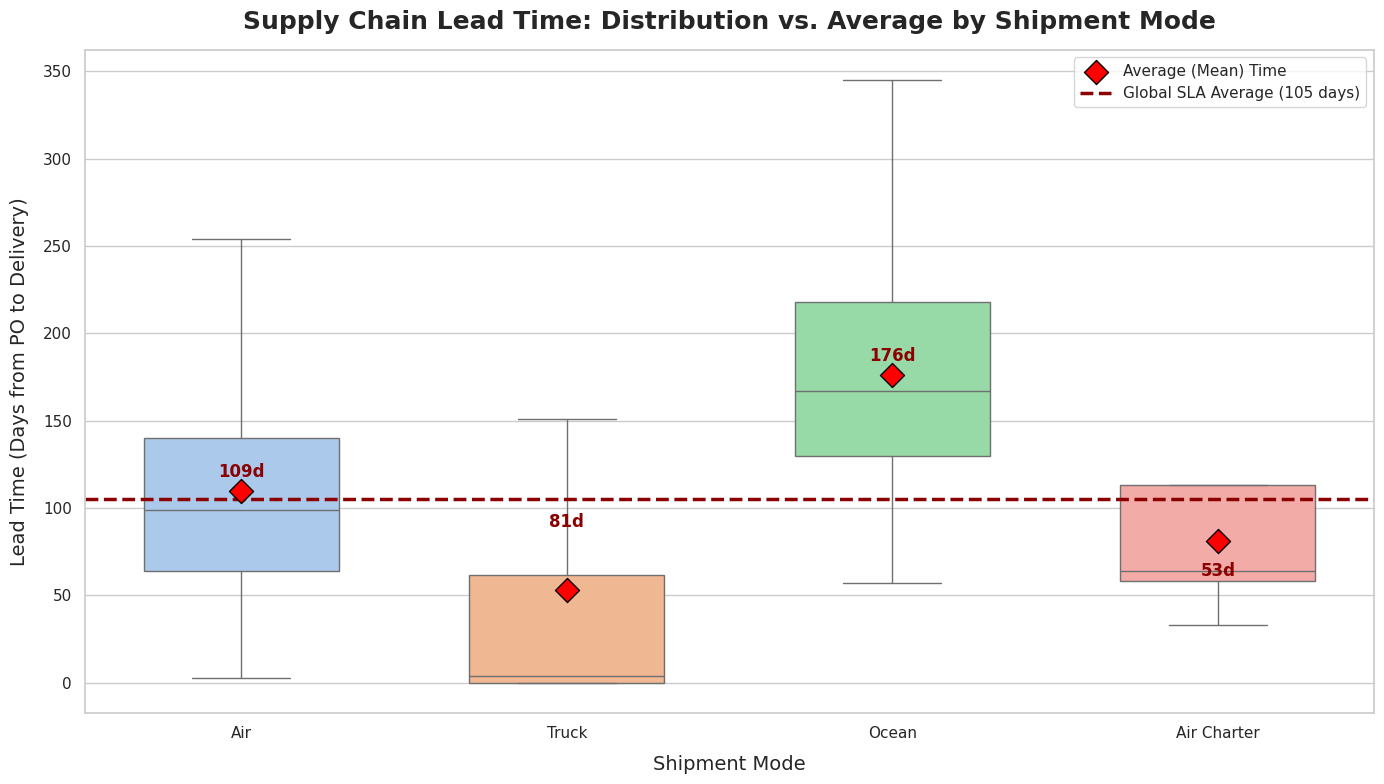

In [23]:
# VISUALIZATION 2: LEAD TIME ANALYTICS

df_valid = df[(df['Lead Time (Days)'] >= 0) & (df['Lead Time (Days)'] <= 400)].copy()
df_valid = df_valid.dropna(subset=['Shipment Mode', 'Lead Time (Days)'])
df_valid = df_valid[~df_valid['Shipment Mode'].isin(['N/A', 'Unknown / Internal Transfer', 'N/A - From RDC'])]

if not df_valid.empty:
    global_avg = df_valid['Lead Time (Days)'].mean()
    plt.figure(figsize=(14, 8))

    sns.boxplot(x='Shipment Mode', y='Lead Time (Days)', data=df_valid, palette='pastel', showfliers=False, width=0.6)

    means = df_valid.groupby('Shipment Mode')['Lead Time (Days)'].mean()
    sns.scatterplot(x=means.index, y=means.values, color='red', marker='D', s=150, label='Average (Mean) Time', zorder=10, edgecolor='black')

    plt.axhline(global_avg, color='darkred', linestyle='--', linewidth=2.5, label=f'Global SLA Average ({global_avg:.0f} days)')

    for i, mode in enumerate(means.index):
        plt.text(i, means[i] + 8, f'{means[i]:.0f}d', ha='center', fontweight='bold', color='darkred', fontsize=12)

    plt.title('Supply Chain Lead Time: Distribution vs. Average by Shipment Mode', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Shipment Mode', fontsize=14, labelpad=10)
    plt.ylabel('Lead Time (Days from PO to Delivery)', fontsize=14, labelpad=10)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

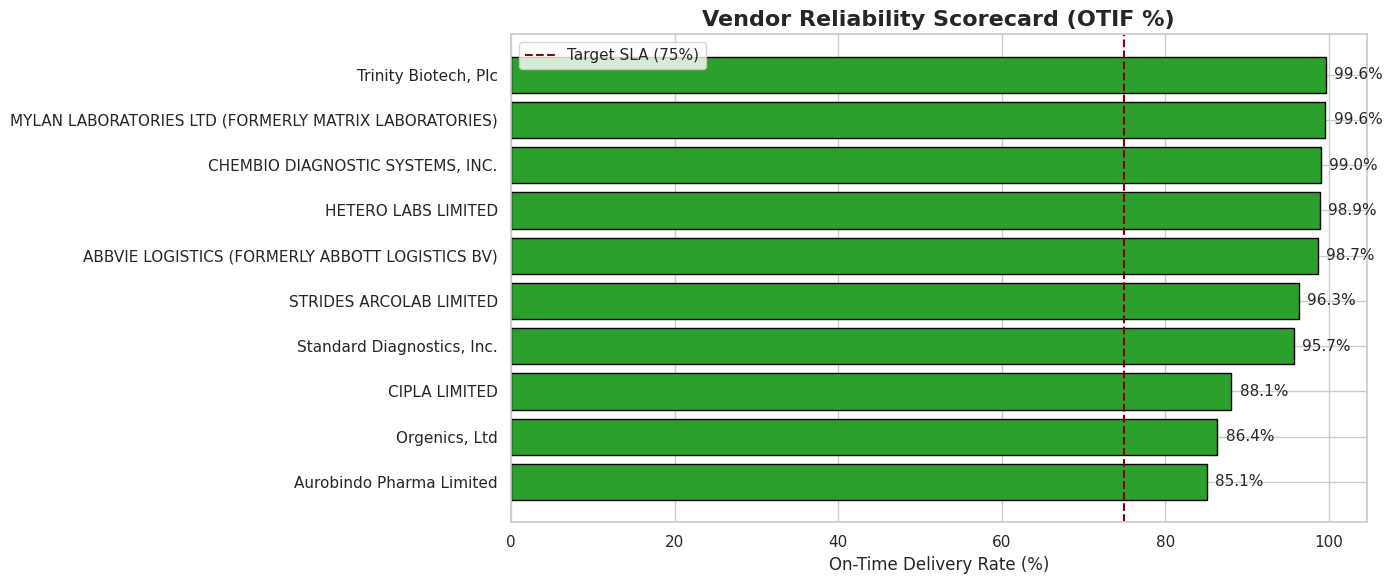

In [24]:
# VISUALIZATION 3: VENDOR OTIF SCORECARD

df_exec = df.dropna(subset=['Vendor', 'On_Time', 'Commodity Value (USD)', 'Freight Cost (USD)'])
df_exec = df_exec[~df_exec['Vendor'].str.contains('SCMS from RDC', na=False)]
top_vendors = df_exec['Vendor'].value_counts().nlargest(10).index
df_vendors = df_exec[df_exec['Vendor'].isin(top_vendors)]

if not df_vendors.empty:
    plt.figure(figsize=(14, 6))
    otif_scores = df_vendors.groupby('Vendor')['On_Time'].mean().sort_values(ascending=True) * 100
    colors = ['#d62728' if x < 70 else '#2ca02c' for x in otif_scores.values]

    ax = plt.subplot(1, 1, 1)
    bars = ax.barh(otif_scores.index, otif_scores.values, color=colors, edgecolor='black')
    ax.set_title('Vendor Reliability Scorecard (OTIF %)', fontsize=16, fontweight='bold')
    ax.set_xlabel('On-Time Delivery Rate (%)')
    ax.axvline(x=75, color='darkred', linestyle='--', label='Target SLA (75%)')
    ax.legend()

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=11)
    plt.tight_layout()
    plt.show()

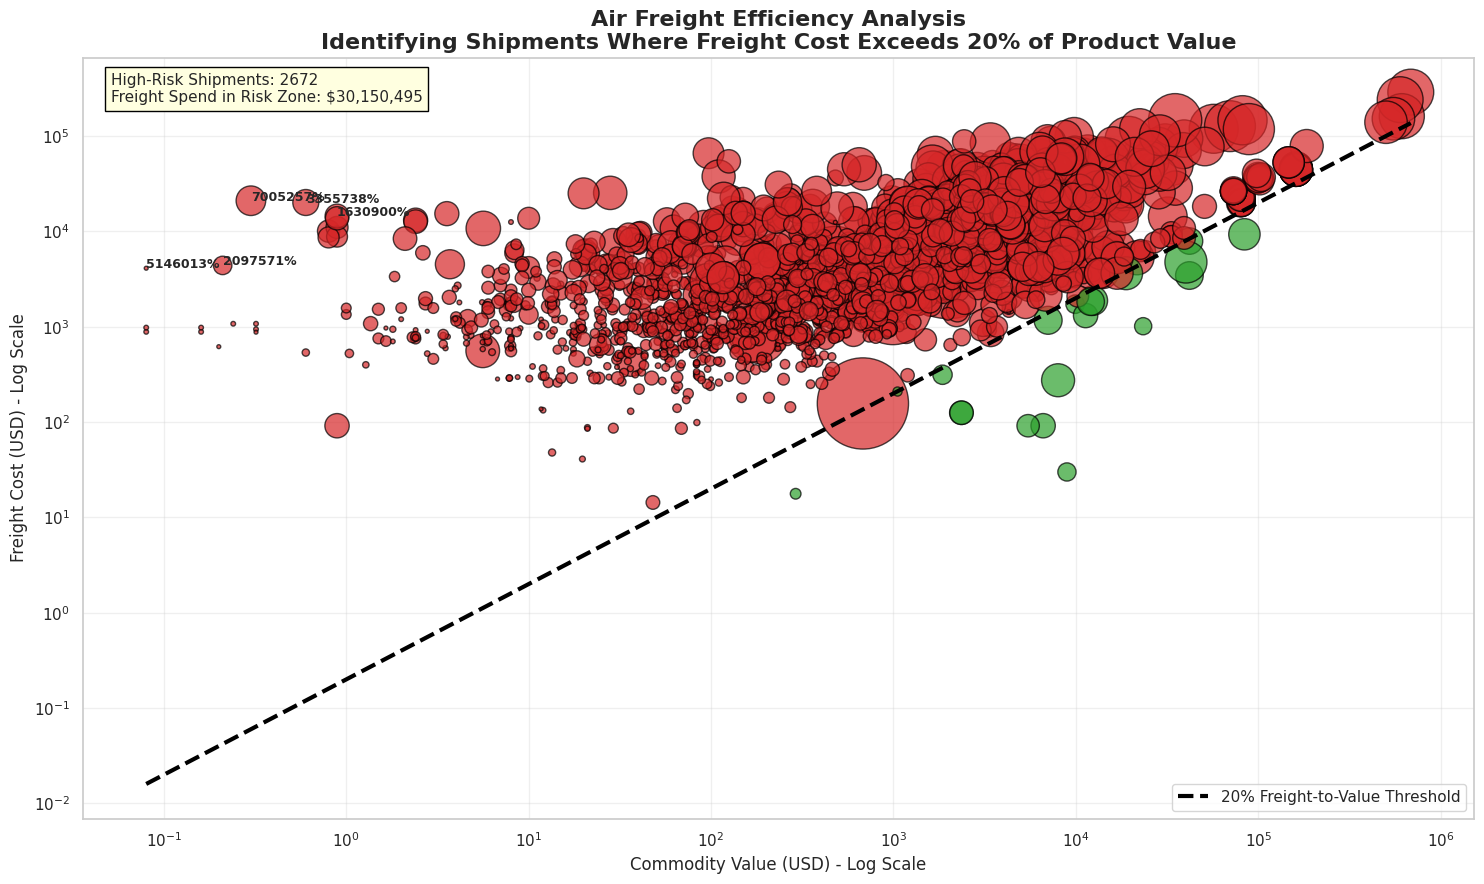

In [25]:
# VISUALIZATION 4: THE "SHIPPING AIR" TRAP

df_air = df_exec[df_exec['Shipment Mode'].str.contains('Air', na=False)].copy()

if not df_air.empty:

    # Clean numeric columns
    df_air['Commodity Value (USD)'] = pd.to_numeric(
        df_air['Commodity Value (USD)'], errors='coerce'
    )

    df_air['Freight Cost (USD)'] = pd.to_numeric(
        df_air['Freight Cost (USD)'], errors='coerce'
    )

    df_air['Weight (Kilograms)'] = pd.to_numeric(
        df_air['Weight (Kilograms)'], errors='coerce'
    ).fillna(1)

    df_air = df_air[
        (df_air['Commodity Value (USD)'] > 0) &
        (df_air['Freight Cost (USD)'] > 0)
    ]

    # Freight % of value
    df_air['Freight %'] = (
        df_air['Freight Cost (USD)']
        / df_air['Commodity Value (USD)']
    ) * 100

    # High-risk shipments
    df_air['Risk'] = np.where(
        df_air['Freight %'] > 20,
        'High Risk',
        'Acceptable'
    )

    plt.figure(figsize=(15, 9))

    sizes = np.sqrt(df_air['Weight (Kilograms)']) * 8

    colors = df_air['Risk'].map({
        'High Risk': '#d62728',
        'Acceptable': '#2ca02c'
    })

    plt.scatter(
        df_air['Commodity Value (USD)'],
        df_air['Freight Cost (USD)'],
        s=sizes,
        c=colors,
        alpha=0.7,
        edgecolor='black'
    )

    # 20% threshold line
    x = np.linspace(
        df_air['Commodity Value (USD)'].min(),
        df_air['Commodity Value (USD)'].max(),
        200
    )

    plt.plot(
        x,
        x * 0.20,
        color='black',
        linestyle='--',
        linewidth=3,
        label='20% Freight-to-Value Threshold'
    )

    # Highlight top 5 worst shipments
    worst = df_air.nlargest(5, 'Freight %')

    for _, row in worst.iterrows():
        plt.annotate(
            f"{row['Freight %']:.0f}%",
            (row['Commodity Value (USD)'],
             row['Freight Cost (USD)']),
            fontsize=9,
            fontweight='bold'
        )

    high_risk_count = (df_air['Freight %'] > 20).sum()

    potential_savings = (
        df_air.loc[df_air['Freight %'] > 20,
                   'Freight Cost (USD)']
        .sum()
    )

    plt.text(
        0.02,
        0.98,
        f"High-Risk Shipments: {high_risk_count}\n"
        f"Freight Spend in Risk Zone: ${potential_savings:,.0f}",
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(facecolor='lightyellow',
                  edgecolor='black')
    )

    plt.xscale('log')
    plt.yscale('log')

    plt.title(
        'Air Freight Efficiency Analysis\n'
        'Identifying Shipments Where Freight Cost Exceeds 20% of Product Value',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Commodity Value (USD) - Log Scale')
    plt.ylabel('Freight Cost (USD) - Log Scale')

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()